In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import time

import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [9]:
regions = ["BLA", "VTA", "CPU", "HIP", "PFC", "NAC"]



['BLA', 'VTA', 'CPU', 'HIP', 'PFC', 'NAC']


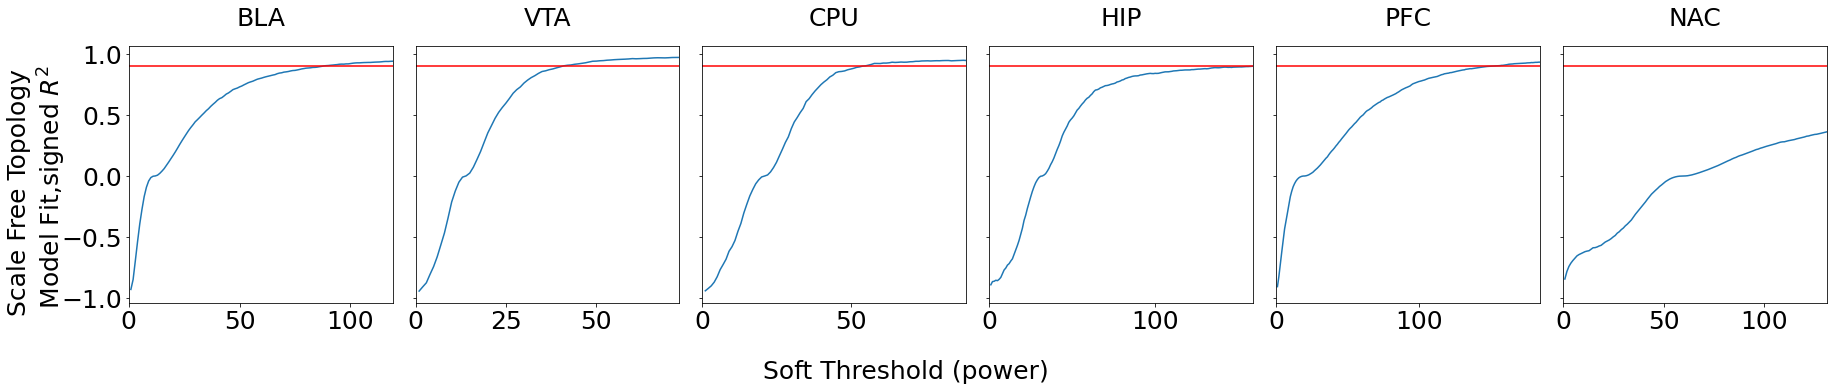

In [10]:
col = len(regions)
row = 1
fig, axes = plt.subplots(row, col, sharey=True)
fig.set_size_inches((26, 5.5))
plt.rc('xtick',labelsize=25)
plt.rc('ytick',labelsize=25)
print(regions)
for i, region in enumerate(regions):
    
    df = pd.read_csv("./20210610_%s_sft.csv" % region, index_col = 0)
    slope_arr = []
    for slope in df["slope"]:
        slope_arr.append(-np.sign(slope))
    
    axes[i].plot(df["Power"], slope_arr*df["SFT.R.sq"])
    axes[i].hlines(y=0.9, xmin=0.0, xmax=df["Power"].values[-1], color='r')
    axes[i].set_xlim(0, df["Power"].values[-1])
    axes[i].set_title("%s" % region, fontsize = 25, pad=20)

# axes[0].set_xlabel("Soft Threshold (power)", fontsize = 25)
# axes[0].set_ylabel(r"Scale Free Topology" + "\n" + r" Model Fit,signed $R^{2}$", fontsize = 25)
fig.supylabel(r"Scale Free Topology" + "\n" + r" Model Fit,signed $R^{2}$", fontsize = 25)
fig.supxlabel("Soft Threshold (power)", fontsize = 25)

fig.tight_layout(pad = 1.5)

In [11]:
melted_df = pd.read_csv("0610_Integrated_Module_AI_alignmnet.csv", index_col = 0) 
pd.set_option('display.max_rows', None)
melted_df[melted_df["Region"] == "NAC"].sort_values(by=['Corr'])

,Region,Mname,Corr,Pvalue,GOterm,Symbols
284,NAC,MEthistle2,-0.622436,0.010024,sperm axoneme assembly,"['C1d: C1D nuclear receptor co-repressor', 'Ca..."
287,NAC,MElightslateblue,-0.604041,0.013211,polysaccharide biosynthetic process,['Baz1b: bromodomain adjacent to zinc finger d...
283,NAC,MEblue2,-0.602363,0.013537,odontogenesis of dentin-containing tooth,"['Vps50: VPS50 EARP/GARPII complex subunit', '..."
275,NAC,MEdarkviolet,-0.585762,0.017115,negative regulation of neurotransmitter transport,"['Spa17: sperm autoantigenic protein 17', 'Lam..."
292,NAC,MEthistle4,-0.581756,0.018079,seminiferous tubule development,['Hnrnpa2b1: heterogeneous nuclear ribonucleop...
251,NAC,MEdarkolivegreen4,-0.567709,0.021797,platelet formation,"['Dlg3: discs large MAGUK scaffold protein 3',..."
252,NAC,MEivory,-0.565604,0.022401,deoxyribonucleotide biosynthetic process,['Bcl11a: B cell CLL/lymphoma 11A (zinc finger...
276,NAC,MEorange,-0.560808,0.023827,protein hexamerization,"['S100a4: S100 calcium binding protein A4', 'B..."
286,NAC,MEdeeppink,-0.556064,0.025304,macrophage activation,['Gabra2: gamma-aminobutyric acid (GABA) A rec...
285,NAC,MEorangered3,-0.545633,0.028799,mRNA modification,"['Prkar2b: protein kinase, cAMP dependent regu..."


# Module-trait alignment (Fig. 1.)

In [15]:
from sklearn.metrics import r2_score

def plot_module_scatter(Mnames):
    region = "NAC"
    fig = plt.figure(figsize = (9, 9))
    x = []
    y = []
    leg = []
    for Mname in Mnames:
        print(region)
        df_EG0_tem = pd.read_csv("../../data/0921/0825_%s-MEs0.csv" % region, index_col = 0)
        df_EG0_sam = pd.read_csv("20210612_%s-MEs0.csv" % region,index_col = 0)

        ordered_AI_index_list = sorted(AI_index_hash.items(), key = lambda item: item[1])
        ordered_AI_index_hash = dict(ordered_AI_index_list)

    #     AI_index = [float(i.split("..")[-1][:-1]) for i in df_EG0_sam.index]
        AI_index = list(ordered_AI_index_hash.values())

    #     df_EG0_sam.index = [i.split("..")[-3] + "_" + i.split("..")[-4] for i in df_EG0_sam[Mname].index]
        df_EG0_sam= df_EG0_sam.reindex([i for i in ordered_AI_index_hash.keys()])
    #     df_EG0_sam.reindex([i.split("..")[-3] + "_" + i.split("..")[-4] for i in ordered_AI_index_hash.keys()])
        plt.scatter(df_EG0_sam[Mname].values, AI_index , linewidth = 4, label = Mname[2:])
        x.extend(df_EG0_sam[Mname].values)
        y.extend(AI_index)
    #     plt.plot(df_EG0_sam[Mname], linewidth = 4, label = Mname)
    #     ax1.set_xticks(["" for ai in AI_index])
        plt.ylim(-0.5, 0.5)

    # ax2.plot(AI_index, color = "black", linewidth = 4, label = "AI")
    # ax2.set_ylim(-0.5, 0.5)
    # ax1.set_xlabel('X data')

    plt.xlabel('Eigen Gene level', fontsize = 25)
    plt.ylabel('Addiction Index', fontsize = 25)
    # plt.plot(AI_index, color = "black", linewidth = 4)
    # plt.title("Eigen Gene comparison in %s" % region, fontsize = 50)
    lines = []
    labels = []

    for ax in fig.axes:
        axLine, axLabel = ax.get_legend_handles_labels()
        lines.extend(axLine)
        labels.extend([ "Module: " + lb.capitalize() for lb in axLabel ])


    plt.legend(lines, labels,loc = 'upper right', fontsize = 16)

    fit_line = np.polyfit(x, y, 1)
    x_minmax = np.array([min(x), max(x)]) # x축 최소값, 최대값
    fit_y = x_minmax * fit_line[0] + fit_line[1] # x축 최소, 최대값을 회귀식에 대입한 값
#     plt.scatter(x, y, color = 'r', s = 20)
    plt.plot(x_minmax, fit_y, color = 'black') 
    est_y = np.array(x) * fit_line[0] + fit_line[1]
    r2 = r2_score(y, est_y)
    plt.text(0.,-0.1, '$R^2$ = %.4f'%r2, size = 16)
    plt.yticks(size=20)
    plt.xticks(size=20)

    # ax1.legend(fontsize = 50)
    # ax2.legend(fontsize = 50)
    plt.show()

In [17]:
AI_index_hash = {}
region ="NAC"
df_EG0_sam = pd.read_csv("20210612_%s-MEs0.csv" % region,index_col = 0)

for ind in df_EG0_sam.index:
    AI_index_hash[ind ] =  float(ind.split("..")[-1][:-1])

NAC
NAC
NAC
NAC


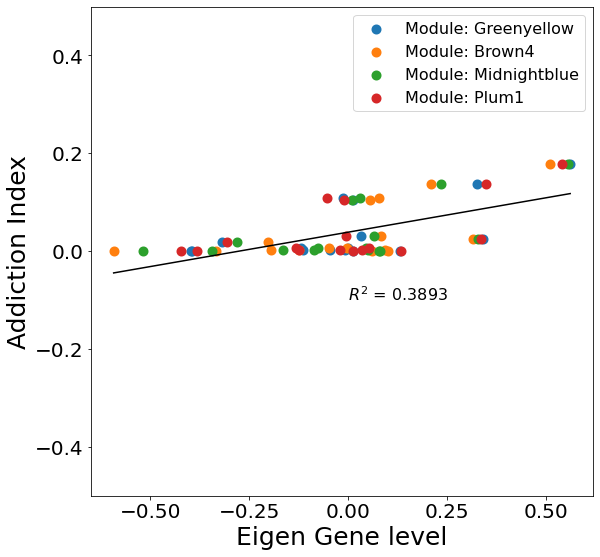

NAC
NAC
NAC
NAC


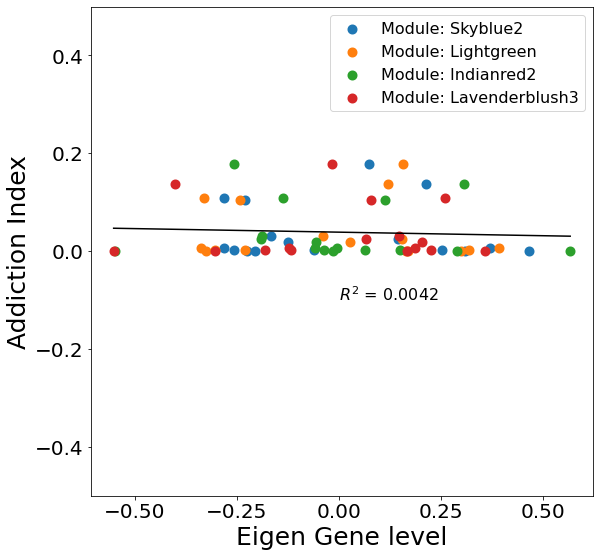

NAC
NAC
NAC
NAC
NAC


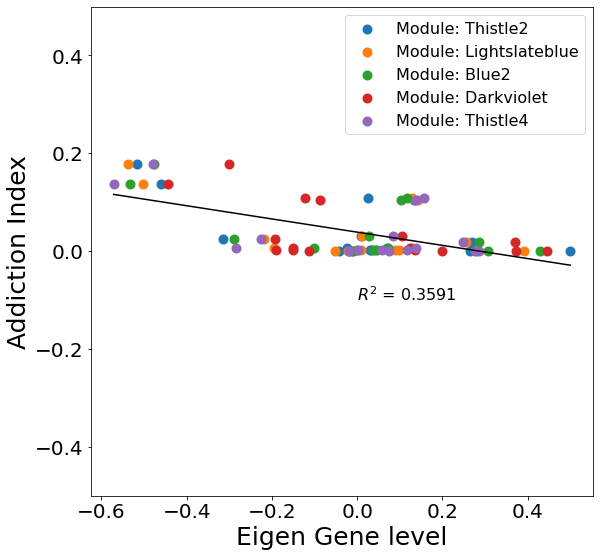

In [18]:
# Mnames = ["MEgreenyellow", "MElightpink4"]
Mnames = ["MEgreenyellow", "MEbrown4", "MEmidnightblue", "MEplum1"]
plot_module_scatter(Mnames)
Mnames = ["MEskyblue2", "MElightgreen", "MEindianred2", "MElavenderblush3"]
plot_module_scatter(Mnames)
Mnames = ["MEthistle2", "MElightslateblue", "MEblue2", "MEdarkviolet", "MEthistle4"]
plot_module_scatter(Mnames)

# Module-trait alignment (Fig. S5.)

In [21]:
def plot_module_EG_AI(Mnames):
    plt.rcParams['font.size'] = 20

    # Mnames = ["MEgreenyellow", "MElightpink4"]
    region = "NAC"
    # plt.figure(figsize = (18, 18))
    fig, ax1 = plt.subplots(figsize = (9, 9))
    # fig, ax1 = plt.subplots(figsize = (18, 18))

    ax2 = ax1.twinx()
    leg = []
    for Mname in Mnames:
        print(region)
        df_EG0_tem = pd.read_csv("../../data/0921/0825_%s-MEs0.csv" % region, index_col = 0)
        df_EG0_sam = pd.read_csv("20210612_%s-MEs0.csv" % region,index_col = 0)

        ordered_AI_index_list = sorted(AI_index_hash.items(), key = lambda item: item[1])
        ordered_AI_index_hash = dict(ordered_AI_index_list)

    #     AI_index = [float(i.split("..")[-1][:-1]) for i in df_EG0_sam.index]
        AI_index = list(ordered_AI_index_hash.values())

    #     df_EG0_sam.index = [i.split("..")[-3] + "_" + i.split("..")[-4] for i in df_EG0_sam[Mname].index]
        df_EG0_sam= df_EG0_sam.reindex([i for i in ordered_AI_index_hash.keys()])
    #     df_EG0_sam.reindex([i.split("..")[-3] + "_" + i.split("..")[-4] for i in ordered_AI_index_hash.keys()])

#         print(df_EG0_sam.index)
        ax1.plot(df_EG0_sam[Mname], linewidth = 4, label = Mname[2:])
#         ax1.yticks(size = 20)

    #     plt.plot(df_EG0_sam[Mname], linewidth = 4, label = Mname)
        ax1.set_xticks(["" for ai in AI_index])
#         ax1.set_ytikcs(size=20)
        ax1.set_ylim(-1.5, 1.5)

    ax2.plot(AI_index, color = "black", linewidth = 4, label = "AI")
#     ax2.set_ytikcs(fontsize=25)
    ax2.set_ylim(-0.5, 0.5)
    # ax1.set_xlabel('X data')

    ax1.set_ylabel('Eigen Gene level', fontsize = 25)
    ax2.set_ylabel('Addiction Index', fontsize = 25)
    # plt.plot(AI_index, color = "black", linewidth = 4)
    # plt.title("Eigen Gene comparison in %s" % region, fontsize = 50)
    lines = []
    labels = []

    for ax in fig.axes:
        axLine, axLabel = ax.get_legend_handles_labels()
        lines.extend(axLine)
        labels.extend([ "Module: " + lb.capitalize() for lb in axLabel ])

    labels[-1] = "Addiction Index"
    ax1.legend(lines, labels,loc = 'upper right', fontsize = 25)
#     plt.yticks(size = 20)

    # ax1.legend(fontsize = 50)
    # ax2.legend(fontsize = 50)
    plt.show()

NAC
NAC
NAC
NAC


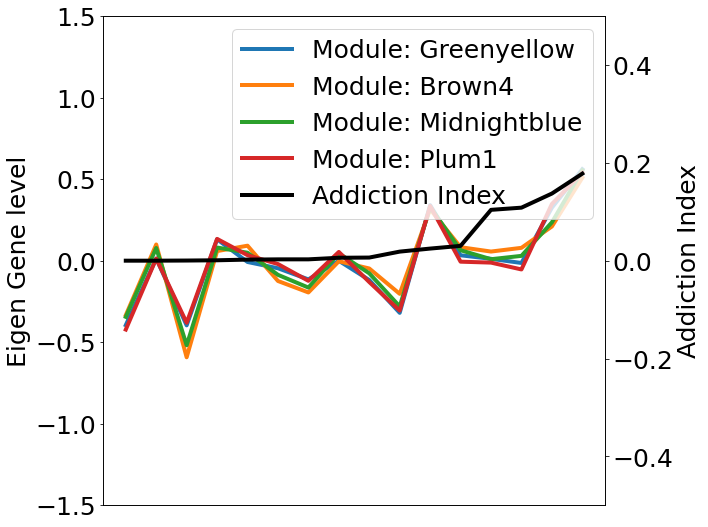

NAC
NAC
NAC
NAC


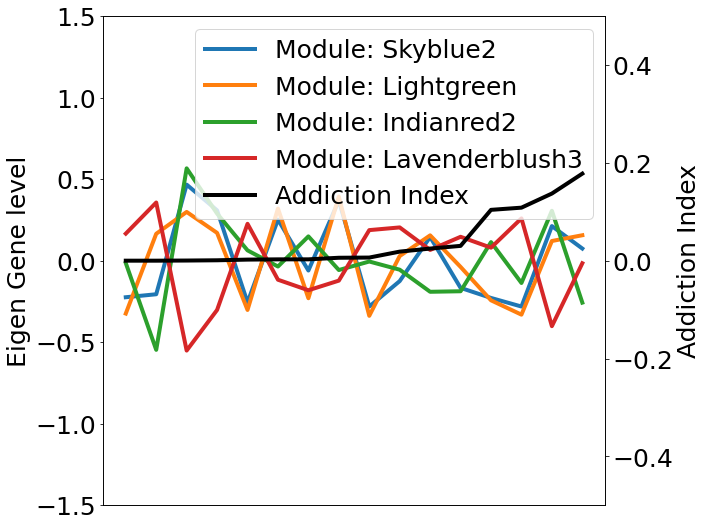

NAC
NAC
NAC
NAC
NAC


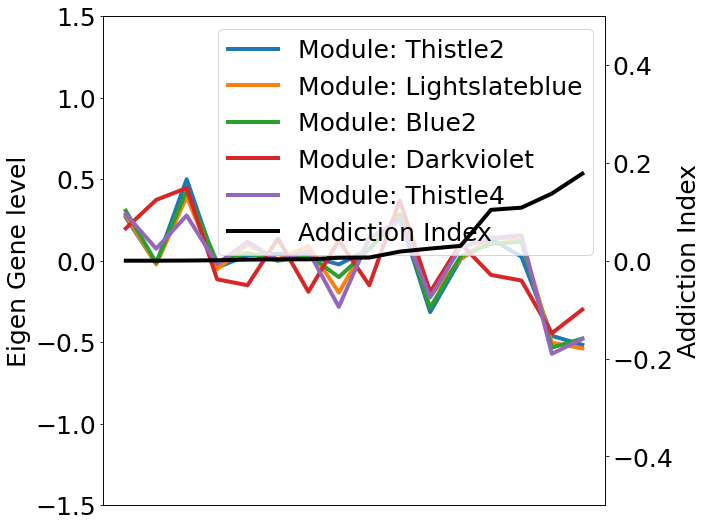

In [22]:
# Mnames = ["MEgreenyellow", "MElightpink4"]
Mnames = ["MEgreenyellow", "MEbrown4", "MEmidnightblue", "MEplum1"]
plot_module_EG_AI(Mnames)
Mnames = ["MEskyblue2", "MElightgreen", "MEindianred2", "MElavenderblush3"]
plot_module_EG_AI(Mnames)
Mnames = ["MEthistle2", "MElightslateblue", "MEblue2", "MEdarkviolet", "MEthistle4"]
plot_module_EG_AI(Mnames)